In [ ]:
# See here https://developers.llamaindex.ai/python/examples/evaluation/questiongeneration/

In [1]:
import nest_asyncio
nest_asyncio.apply()


In [2]:
# 1.0 Call libraries
# https://developers.llamaindex.ai/python/framework-api-reference/evaluation/dataset_generation/#llama_index.core.evaluation.DatasetGenerator
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.core import Settings
# 1.1
from llama_index.core.evaluation import DatasetGenerator, RelevancyEvaluator
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Response

/home/ashok/langchain/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.3.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [3]:
# 1.1 Configure the llm
llm = Ollama(model="llama3.2:3b-instruct-q8_0",
             request_timeout=3600.0,
             temperature = 0.9
            )

Settings.llm = llm

# 1.2 Global Embedding Model
Settings.embed_model = OllamaEmbedding(
                                       model_name="nomic-embed-text"
                                      )

/home/ashok/langchain/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [48]:
# For logging.
# Not clear
import logging
import sys
import pandas as pd

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
logging.getLogger().addHandler(logging.StreamHandler(stream=sys.stdout))

In [7]:
# DatasetGenerator is question generator
from llama_index.core.evaluation import DatasetGenerator, RelevancyEvaluator
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Response

In [8]:
# Load files
path = "/home/ashok/Documents/scorders/txt_files/"
reader = SimpleDirectoryReader(path)
documents = reader.load_data()

This will print the word count for each document. You can also access other attributes like doc.doc_id or doc.metadata as needed. According to SimpleDirectoryReader documentation, documents is a list of Document objects, each with a .text field.

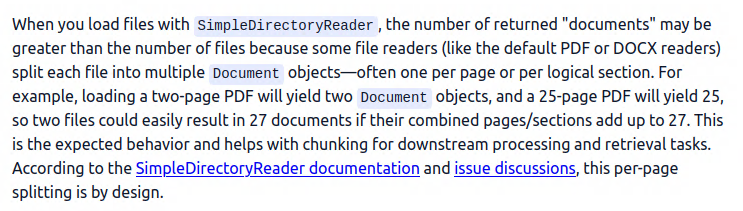

In [13]:
# How many documents? 
#  A document is generally one page

print(f"Loaded {len(documents)} documents")

Loaded 27 documents


In [14]:
# How many words per doc
for doc in documents:
    print(len(doc.text.split()))

150
313
318
265
246
289
319
326
306
367
499
407
270
302
379
347
359
261
272
226
270
256
313
329
377
74
1026


In [53]:
# See below discussion on chunk-size
data_generator = DatasetGenerator.from_documents(documents,
                                                  llm = llm,
                                                  num_questions_per_chunk=3,  # Default is 10
                                                                              # How is chink size fixed?
                                                  show_progress=True 
                                                 )

Applying transformations: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 151.62it/s]
/home/ashok/langchain/lib/python3.13/site-packages/llama_index/core/evaluation/dataset_generation.py:201: DeprecationWarning: Call to deprecated class DatasetGenerator. (Deprecated in favor of `RagDatasetGenerator` which should be used instead.)
  return cls(


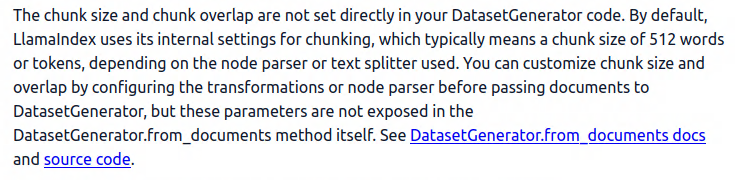

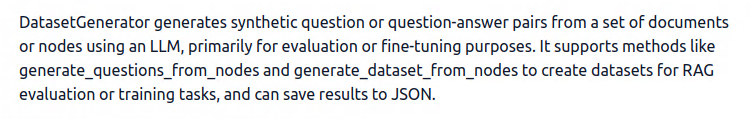

To explicitly set chunk size and chunk overlap, you should configure a text splitter (such as SentenceSplitter or TokenTextSplitter) and pass it as a transformation to the DatasetGenerator. This ensures your documents are split into nodes according to your desired chunking parameters before question generation.

For example, using SentenceSplitter:

In [15]:
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.evaluation import DatasetGenerator

splitter = SentenceSplitter(chunk_size=512, chunk_overlap=50)
data_generator = DatasetGenerator.from_documents(
                                                documents,
                                                llm=llm,
                                                num_questions_per_chunk=3,
                                                transformations=[splitter],  # Pass your custom splitter here
                                                show_progress=True
                                                )


Applying transformations: 100%|███████████████████████████████████████| 1/1 [00:00<00:00,  2.03it/s]
/home/ashok/langchain/lib/python3.13/site-packages/llama_index/core/evaluation/dataset_generation.py:201: DeprecationWarning: Call to deprecated class DatasetGenerator. (Deprecated in favor of `RagDatasetGenerator` which should be used instead.)
  return cls(


Alternatively, you can set global defaults using Settings.    
For what all can be set globally, see [here](https://developers.llamaindex.ai/python/framework/module_guides/supporting_modules/settings/#starlight__mobile-toc)

In [ ]:
from llama_index.core import Settings
Settings.chunk_size = 512
Settings.chunk_overlap = 50


In [16]:
%%time
# num_questions_per_chunk=5,
# show_progress=True,
eval_questions = data_generator.generate_questions_from_nodes()

2026-04-21 11:57:25,548 - INFO - HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
100%|███████████████████████████████████████████████████████████████| 43/43 [08:02<00:00, 11.21s/it]

CPU times: user 273 ms, sys: 36 ms, total: 309 ms
Wall time: 8min 2s



/home/ashok/langchain/lib/python3.13/site-packages/llama_index/core/evaluation/dataset_generation.py:297: DeprecationWarning: Call to deprecated class QueryResponseDataset. (Deprecated in favor of `LabelledRagDataset` which should be used instead.)
  return QueryResponseDataset(queries=queries, responses=responses_dict)


In [17]:
eval_questions

['Here are three diverse questions based on the provided context:',
 'What is the number of members in Pujari Utthan Avam Kalyan Samiti, as per the association registered under the M.P Society Registrikaran Adhiniyam 1973?',
 'In what year did the Madhya Pradesh High Court pass an intra-court appeal order that was challenged by the State of Madhya Pradesh in a writ petition?',
 'What is the nature of the challenge made by the Association of Priests registered under the M.P Society Registrikaran Adhiniyam 1973, which led to the issuance of circulars dated 21.03.1994 and 07.06.2008?',
 'Here are three questions based on the given context information:',
 "What was the basis of the High Court's decision to quash the circular dated 07.06.2008?",
 'According to which judgment, Pujaris have no right to alienate the properties of the temple?',
 'On what grounds did the Single Bench quash the circulars dated 12.11.1992 and 21.03.1994?',
 'Here are three questions based on the given context info

In [18]:
# 1.1 Configure the llm
llm = Ollama(model="qwen3.5:latest",
             request_timeout=3600.0,
             temperature = 0.9
            )


In [19]:
evaluator_llm = RelevancyEvaluator(llm=llm)

In [20]:
# create vector index
vector_index = VectorStoreIndex.from_documents(documents)

2026-04-21 12:15:09,171 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-04-21 12:15:12,792 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-04-21 12:15:16,330 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"


In [21]:
# define jupyter display function
def display_eval_df(query: str, response: Response, eval_result: str) -> None:
    eval_df = pd.DataFrame(
        {
            "Query": query,
            "Response": str(response),
            "Source": (
                response.source_nodes[0].node.get_content()[:1000] + "..."
            ),
            "Evaluation Result": eval_result,
        },
        index=[0],
    )
    eval_df = eval_df.style.set_properties(
        **{
            "inline-size": "600px",
            "overflow-wrap": "break-word",
        },
        subset=["Response", "Source"],
    )
    display(eval_df)

In [22]:
query_engine = vector_index.as_query_engine()

In [23]:
response_vector = query_engine.query(eval_questions[1])
eval_result = evaluator_llm.evaluate_response(
                                               query=eval_questions[1],
                                               response=response_vector
                                              )

2026-04-21 12:15:28,211 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-04-21 12:15:37,951 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
2026-04-21 12:15:38,114 - INFO - HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
2026-04-21 12:18:32,703 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


In [25]:
# See here:
# https://developers.llamaindex.ai/python/framework/module_guides/evaluating/usage_pattern/
import pandas as pd
df = pd.DataFrame([eval_result.__dict__])
print(df.T)  # Transpose for vertical display

                                                                 0
query            What is the number of members in Pujari Utthan...
contexts         [REPORTABLE\nIN THE SUPREME COURT OF INDIA\nCI...
response                                                      251.
passing                                                       True
feedback                                                       YES
score                                                          1.0
pairwise_source                                               None
invalid_result                                               False
invalid_reason                                                None


In [28]:
import pandas as pd

# Convert EvaluationResult to a dictionary and transpose for readability
df = pd.DataFrame([eval_result.__dict__]).T
df.columns = ['Value']  # Rename the value column
df.index.name = 'Field'  # Name the index

# Optional: pretty print with styling in Jupyter
from IPython.display import display
display(df.style.set_properties(**{'background-color': '#f9f9f9', 'border': '1px solid #ccc'}))


,Value
Field,
query,"What is the number of members in Pujari Utthan Avam Kalyan Samiti, as per the association registered under the M.P Society Registrikaran Adhiniyam 1973?"
contexts,"['REPORTABLE\nIN THE SUPREME COURT OF INDIA\nCIVIL APPELLATE JURISDICTION\nCIVIL APPEAL NO. 4850 OF 2021\n(ARISING OUT OF SLP (CIVIL) NO. 33675 OF 2017)\nThe STATE OF MADHYA PRADESH & ORS. .....APPELLANT(S)\nVERSUS\nPUJARI UTTHAN AVAM KALYAN SAMITI & ANR.\n.....RESPONDENT(S)\nJ U D G M E N T\nHEMANT GUPTA, J.\n1. The order dated 14.06.2016 passed in an intra-court appeal by the\nDivision Bench of the Madhya Pradesh High Court is the subject matter\nof challenge herein at the instance of State of Madhya Pradesh. The\nlearned Single Bench allowed the writ petition filed by Association of\nPriests registered under the M.P . Society Registrikaran Adhiniyam 1973.\nSuch society has 251 members in the Districts of Dhar, Indore, Ratlam,\nShajapur, Ujjain, Jhabua etc.\n2. The challenge in the writ petition was to quash the circulars dated\n21.03.1994 and 07.06.2008 whereby the names of Pujari were ordered\n1', 'date in any of the judgments to hold that the name of Pujari or man -\nager is required to be mentioned in the revenue record.\n26. In terms of Section 108, 109 and 110 of the Code, Rules had been\nframed initially as Appendix X. Form A has been prescribed as per Rule\n2. Later such Rules were substituted by another Rules published on\n15.5.1964 and Form I was prescribed to maintain the records of the\nrights. Such Rules have been further substituted on 20 th December\n1983, published in the Madhya Pradesh Gazette. The Column 3 of such\nForm is to contain name and address of the occupier, whereas Column\n4 is required to contain name of the tenant or sub-lessee of an occu -\npancy tenant of the Bhumiswami. Column 12 is meant for remarks.\nThe relevant Rules read as under:-\nPart II – KHASRA.\n“6. The Patwari shall prepare each agricultural year a khasra\nfor each village that has been completely surveyed in his circle\nin Form I.\n7. The khasra shall be written up in the field by the Patwari af-\nter local enquiry and actual inspections. A separate entry shall\nbe made for every plot, and every plot, whether cultivated or\nnot shall be entered.\nProvided that small baris situated within the village\nside and included in the village abadi plot, shall not be shown\nseparately but included in the abadi area.\n8. Entries shall be made by the Patwari according to facts\nfound by him during local inspection.\n22']"
response,251.
passing,True
feedback,YES
score,1.000000
pairwise_source,None
invalid_result,False
invalid_reason,None
